# XG Boost Model

### Import Libraries

In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, f1_score, r2_score, log_loss
import matplotlib.pyplot as plt
import seaborn as sns
import random

# ignore warnings (libraries are rapidly changing)
import warnings
warnings.filterwarnings('ignore')

### Read Data

In [2]:
X_train = pd.read_csv("/Users/sarahfarooq/Desktop/Master's/DATASCI 207/X_train.csv")
X_test = pd.read_csv("/Users/sarahfarooq/Desktop/Master's/DATASCI 207/X_test.csv")
X_val = pd.read_csv("/Users/sarahfarooq/Desktop/Master's/DATASCI 207/X_val.csv")
y_train = pd.read_csv("/Users/sarahfarooq/Desktop/Master's/DATASCI 207/y_train.csv")
y_test = pd.read_csv("/Users/sarahfarooq/Desktop/Master's/DATASCI 207/y_test.csv")
y_val = pd.read_csv("/Users/sarahfarooq/Desktop/Master's/DATASCI 207/y_val.csv")

# print shapes
print('Shape of X_train images ', X_train.shape)
print('Shape of y_train labels ', y_train.shape)

print('Shape of X_val images ', X_val.shape)
print('Shape of y_val labels ', y_val.shape)

print('Shape of X_test images ', X_test.shape)
print('Shape of y_test labels ', y_test.shape)

Shape of X_train images  (12426, 345)
Shape of y_train labels  (12426, 3)
Shape of X_val images  (4142, 345)
Shape of y_val labels  (4142, 3)
Shape of X_test images  (4142, 345)
Shape of y_test labels  (4142, 3)


### Split y data into 3, 7, and 14 days

In [3]:
# For y_3
y_train_3 = y_train[['y_3']]
y_test_3 = y_test[['y_3']]
y_val_3 = y_val[['y_3']]

# For y_7
y_train_7 = y_train[['y_7']]
y_test_7 = y_test[['y_7']]
y_val_7 = y_val[['y_7']]

# For y_14
y_train_14 = y_train[['y_14']]
y_test_14 = y_test[['y_14']]
y_val_14 = y_val[['y_14']]

### Split X data into 3, 7, and 14 days

In [4]:
# X_train_3, X_test_3, X_val_3
# Filter out columns that end with 'LAG_7' or 'LAG_14'
columns_to_keep_3 = [col for col in X_train.columns if not (col.endswith('LAG_7') or col.endswith('LAG_14'))]

# Create the new dataframes
X_train_3 = X_train[columns_to_keep_3]
X_test_3 = X_test[columns_to_keep_3]
X_val_3 = X_val[columns_to_keep_3]

# X_train_7, X_test_7, X_val_7
# Filter out columns that end with 'LAG_3' or 'LAG_14'
columns_to_keep_7 = [col for col in X_train.columns if not (col.endswith('LAG_3') or col.endswith('LAG_14'))]

# Create the new dataframes
X_train_7 = X_train[columns_to_keep_7]
X_test_7 = X_test[columns_to_keep_7]
X_val_7 = X_val[columns_to_keep_7]

# X_train_14, X_test_14, X_val_14
# Filter out columns that end with 'LAG_3' or 'LAG_7'
columns_to_keep_14 = [col for col in X_train.columns if not (col.endswith('LAG_3') or col.endswith('LAG_7'))]

# Create the new dataframes
X_train_14 = X_train[columns_to_keep_14]
X_test_14 = X_test[columns_to_keep_14]
X_val_14 = X_val[columns_to_keep_14]

### Encode any columns that have dtype 'object'

In [5]:
def encode_object_columns(df):
    df_encoded = df.copy()
    for col in df_encoded.columns:
        if df_encoded[col].dtype == 'object':
            df_encoded[col] = LabelEncoder().fit_transform(df_encoded[col].astype(str))
    return df_encoded

# 3-day data
X_train_3 = encode_object_columns(X_train_3)
X_val_3 = encode_object_columns(X_val_3)
X_test_3 = encode_object_columns(X_test_3)

# 7-day data
X_train_7 = encode_object_columns(X_train_7)
X_val_7 = encode_object_columns(X_val_7)
X_test_7 = encode_object_columns(X_test_7)

# 14-day data
X_train_14 = encode_object_columns(X_train_14)
X_val_14 = encode_object_columns(X_val_14)
X_test_14 = encode_object_columns(X_test_14)

### Define XG Boost model function

In [6]:
def run_xgboost_model(X_train, y_train, X_val, y_val, X_test, y_test, 
                      n_estimators, max_depth, learning_rate, label_days,
                      reg_alpha=0, reg_lambda=0, min_child_weight=0,
                      gamma=0, subsample=0, colsample_bytree=0):
    # Initialize XGBoost classifier
    xgb = XGBClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        learning_rate=learning_rate,
        use_label_encoder=False,
        eval_metric='logloss'
    )

    # Train model
    xgb.fit(X_train, y_train)

    # Predict labels
    y_train_pred = xgb.predict(X_train)
    y_val_pred = xgb.predict(X_val)
    y_test_pred = xgb.predict(X_test)

    # Predict probabilities
    y_train_proba = xgb.predict_proba(X_train)
    y_val_proba = xgb.predict_proba(X_val)
    y_test_proba = xgb.predict_proba(X_test)

    # Accuracy
    print(f"\n XGBoost Model for Fire in {label_days} Days")
    print("Training Accuracy:", round(accuracy_score(y_train, y_train_pred) * 100, 2), "%")
    print("Validation Accuracy:", round(accuracy_score(y_val, y_val_pred) * 100, 2), "%")
    print("Test Accuracy:", round(accuracy_score(y_test, y_test_pred) * 100, 2), "%")

    # Additional metrics per dataset
    for label, y_true, y_pred, y_proba in [
        ("Training", y_train, y_train_pred, y_train_proba),
        ("Validation", y_val, y_val_pred, y_val_proba),
        ("Test", y_test, y_test_pred, y_test_proba)
    ]:
        print(f"\n {label} Metrics:")
        print("Precision :", round(precision_score(y_true, y_pred, average='weighted', zero_division=0) * 100, 2), "%")
        print("Recall    :", round(recall_score(y_true, y_pred, average='weighted', zero_division=0) * 100, 2), "%")
        print("F1 Score  :", round(f1_score(y_true, y_pred, average='weighted', zero_division=0) * 100, 2), "%")
        print("R² Score  :", round(r2_score(y_true, y_pred), 4))
        print("Log Loss  :", round(log_loss(y_true, y_proba), 4))

    # Confusion matrix for validation set
    cm = confusion_matrix(y_val, y_val_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Oranges")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title(f"Confusion Matrix (Validation) - Fire in {label_days} Days")
    plt.show()


### Run XG Boost to predict fires in 3 days


 XGBoost Model for Fire in 3 Days
Training Accuracy: 69.72 %
Validation Accuracy: 56.88 %
Test Accuracy: 53.38 %

 Training Metrics:
Precision : 68.34 %
Recall    : 69.72 %
F1 Score  : 68.19 %
R² Score  : 0.3375
Log Loss  : 0.8682

 Validation Metrics:
Precision : 54.81 %
Recall    : 56.88 %
F1 Score  : 54.61 %
R² Score  : 0.1144
Log Loss  : 1.3614

 Test Metrics:
Precision : 51.02 %
Recall    : 53.38 %
F1 Score  : 51.24 %
R² Score  : 0.0096
Log Loss  : 1.443


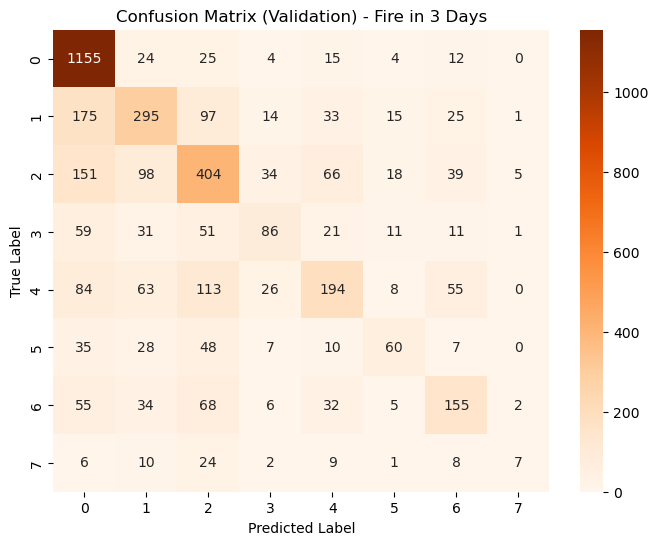

In [7]:
# Fire in 3 days
run_xgboost_model(X_train_3, y_train_3, X_val_3, y_val_3, X_test_3, y_test_3, 
                  n_estimators=250, max_depth=4, learning_rate=0.03, label_days=3)

### Run XG Boost to predict fires in 7 days


 XGBoost Model for Fire in 7 Days
Training Accuracy: 61.86 %
Validation Accuracy: 40.92 %
Test Accuracy: 40.87 %

 Training Metrics:
Precision : 63.94 %
Recall    : 61.86 %
F1 Score  : 60.25 %
R² Score  : 0.2523
Log Loss  : 1.1555

 Validation Metrics:
Precision : 40.63 %
Recall    : 40.92 %
F1 Score  : 36.9 %
R² Score  : -0.1475
Log Loss  : 1.6679

 Test Metrics:
Precision : 39.03 %
Recall    : 40.87 %
F1 Score  : 37.03 %
R² Score  : -0.1695
Log Loss  : 1.6452


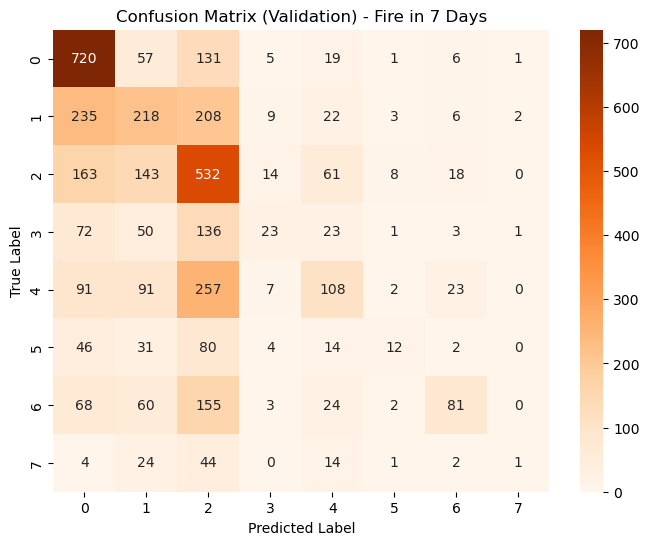

In [8]:
# Fire in 7 days
run_xgboost_model(X_train_7, y_train_7, X_val_7, y_val_7, X_test_7, y_test_7, 
                  n_estimators=300, max_depth=5, learning_rate=0.01, label_days=7)

### Run XG Boost to predict fires in 14 days


 XGBoost Model for Fire in 14 Days
Training Accuracy: 65.96 %
Validation Accuracy: 31.89 %
Test Accuracy: 33.51 %

 Training Metrics:
Precision : 68.68 %
Recall    : 65.96 %
F1 Score  : 65.55 %
R² Score  : 0.3467
Log Loss  : 1.0069

 Validation Metrics:
Precision : 31.44 %
Recall    : 31.89 %
F1 Score  : 27.38 %
R² Score  : -0.3722
Log Loss  : 1.9437

 Test Metrics:
Precision : 29.96 %
Recall    : 33.51 %
F1 Score  : 28.39 %
R² Score  : -0.2896
Log Loss  : 1.8712


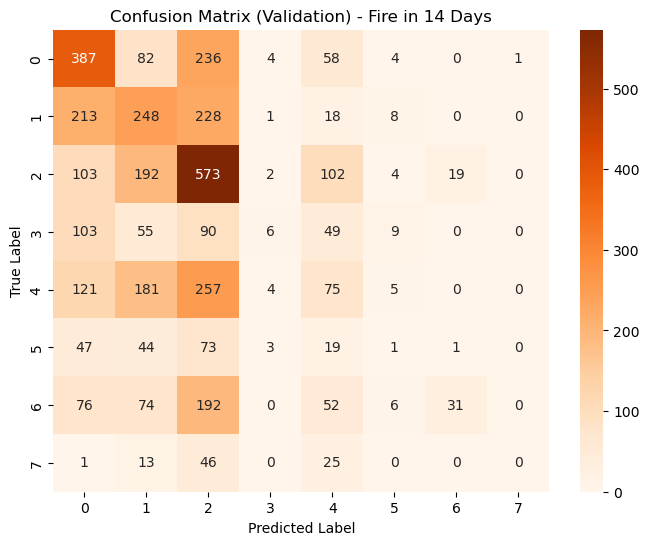

In [9]:
# Fire in 14 days
run_xgboost_model(X_train_14, y_train_14, X_val_14, y_val_14, X_test_14, y_test_14, 
                  n_estimators=250, max_depth=4, learning_rate=0.05, label_days=14)

### Experiments - Hyperparameter tuning to find the best hyperparameters

In [16]:
def run_random_search(X_train, y_train, X_val, y_val, X_test, y_test, label_days, n_iter=20):
    best_f1 = -1
    best_params = None
    best_model = None

    for _ in range(n_iter):
        # Randomly sample hyperparameters
        params = {
            "n_estimators": random.choice([200, 250, 300, 350, 400]),
            "max_depth": random.choice([1, 2, 3, 4, 5]),
            "learning_rate": random.choice([0.01, 0.02, 0.03, 0.04, 0.05]),
            "reg_alpha": random.choice([0, 0.3, 0.5, 0.6, 0.8]),
            "reg_lambda": random.choice([0.5, 1.0, 1.5, 2.0, 2.5]),
            "min_child_weight": random.choice([0, 1, 2, 3, 5]),
            "gamma": random.choice([0, 0.1, 0.2, 0.3, 0.4]),
            "subsample": random.choice([0.7, 0.8, 0.9, 1.0]),
            "colsample_bytree": random.choice([0.3, 0.6, 0.8, 1.0])
        }

        xgb = XGBClassifier(
            **params,
            use_label_encoder=False,
            eval_metric='logloss'
        )

        xgb.fit(X_train, y_train)
        y_val_pred = xgb.predict(X_val)
        f1 = f1_score(y_val, y_val_pred, average='weighted', zero_division=0)

        if f1 > best_f1:
            best_f1 = f1
            best_params = params
            best_model = xgb

    # Final evaluation
    print("\n Best Hyperparameters Found:")
    for k, v in best_params.items():
        print(f"  {k}: {v}")

    # Predictions
    y_train_pred = best_model.predict(X_train)
    y_val_pred = best_model.predict(X_val)
    y_test_pred = best_model.predict(X_test)
    
    # Probabilities for log loss
    y_train_proba = best_model.predict_proba(X_train)
    y_val_proba = best_model.predict_proba(X_val)
    y_test_proba = best_model.predict_proba(X_test)
    
    # Final accuracy
    print("\n Final Accuracy:")
    print(f"  Train Accuracy: {round(accuracy_score(y_train, y_train_pred) * 100, 2)}%")
    print(f"  Validation Accuracy: {round(accuracy_score(y_val, y_val_pred) * 100, 2)}%")
    print(f"  Test Accuracy: {round(accuracy_score(y_test, y_test_pred) * 100, 2)}%")
    
    # Final log loss
    print("\n Final Log Loss:")
    print(f"  Train Log Loss: {round(log_loss(y_train, y_train_proba), 4)}")
    print(f"  Validation Log Loss: {round(log_loss(y_val, y_val_proba), 4)}")
    print(f"  Test Log Loss: {round(log_loss(y_test, y_test_proba), 4)}")
    
    # Additional test metrics
    print(f"\n Test Set Metrics (Label: {label_days} Days):")
    print("  Precision :", round(precision_score(y_test, y_test_pred, average='weighted', zero_division=0) * 100, 2), "%")
    print("  Recall    :", round(recall_score(y_test, y_test_pred, average='weighted', zero_division=0) * 100, 2), "%")
    print("  F1 Score  :", round(f1_score(y_test, y_test_pred, average='weighted', zero_division=0) * 100, 2), "%")
    print("  R² Score  :", round(r2_score(y_test, y_test_pred), 4))

    # Confusion matrix for test set
    cm = confusion_matrix(y_test, y_test_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Oranges")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title(f"Confusion Matrix (Test) - Fire in {label_days} Days")
    plt.show()


### Experiment with hyperparameters to predict fires in 3 days


 Best Hyperparameters Found:
  n_estimators: 250
  max_depth: 1
  learning_rate: 0.02
  reg_alpha: 0.3
  reg_lambda: 2.0
  min_child_weight: 1
  gamma: 0.4
  subsample: 1.0
  colsample_bytree: 1.0

 Final Accuracy:
  Train Accuracy: 65.31%
  Validation Accuracy: 57.65%
  Test Accuracy: 54.23%

 Final Log Loss:
  Train Log Loss: 1.1292
  Validation Log Loss: 1.3624
  Test Log Loss: 1.435

 Test Set Metrics (Label: 3 Days):
  Precision : 52.46 %
  Recall    : 54.23 %
  F1 Score  : 52.53 %
  R² Score  : -0.0007


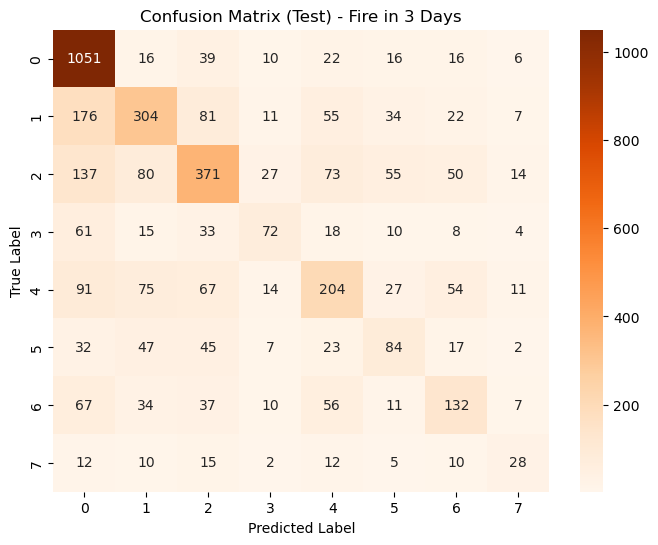

In [17]:
run_random_search(X_train_3, y_train_3, X_val_3, y_val_3, X_test_3, y_test_3, label_days=3, n_iter=20)

### Experiment with hyperparameters to predict fires in 7 days


 Best Hyperparameters Found:
  n_estimators: 200
  max_depth: 5
  learning_rate: 0.04
  reg_alpha: 0.3
  reg_lambda: 1.0
  min_child_weight: 5
  gamma: 0
  subsample: 0.8
  colsample_bytree: 0.3

 Final Accuracy:
  Train Accuracy: 66.87%
  Validation Accuracy: 41.26%
  Test Accuracy: 40.58%

 Final Log Loss:
  Train Log Loss: 0.9679
  Validation Log Loss: 1.6849
  Test Log Loss: 1.6659

 Test Set Metrics (Label: 7 Days):
  Precision : 39.29 %
  Recall    : 40.58 %
  F1 Score  : 36.89 %
  R² Score  : -0.1921


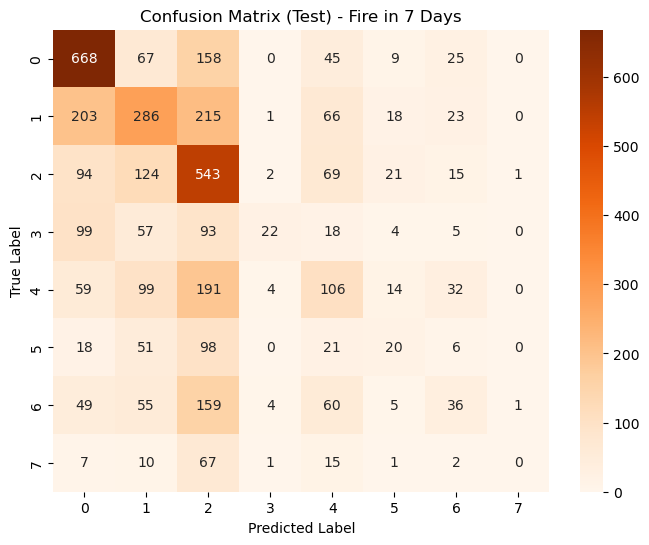

In [12]:
run_random_search(X_train_7, y_train_7, X_val_7, y_val_7, X_test_7, y_test_7, label_days=7, n_iter=20)

### Experiment with hyperparameters to predict fires in 14 days


 Best Hyperparameters Found:
  n_estimators: 300
  max_depth: 3
  learning_rate: 0.03
  reg_alpha: 0.8
  reg_lambda: 0.5
  min_child_weight: 3
  gamma: 0.3
  subsample: 1.0
  colsample_bytree: 0.3

 Final Accuracy:
  Train Accuracy: 52.8%
  Validation Accuracy: 32.3%
  Test Accuracy: 33.82%

 Final Log Loss:
  Train Log Loss: 1.2799
  Validation Log Loss: 1.8508
  Test Log Loss: 1.8039

 Test Set Metrics (Label: 14 Days):
  Precision : 34.7 %
  Recall    : 33.82 %
  F1 Score  : 28.43 %
  R² Score  : -0.2736


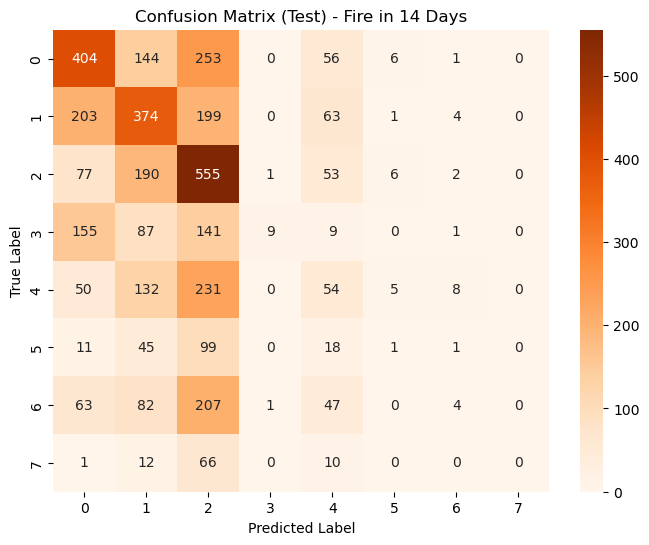

In [13]:
run_random_search(X_train_14, y_train_14, X_val_14, y_val_14, X_test_14, y_test_14, label_days=14, n_iter=20)

### Graph of Final Model Metrics

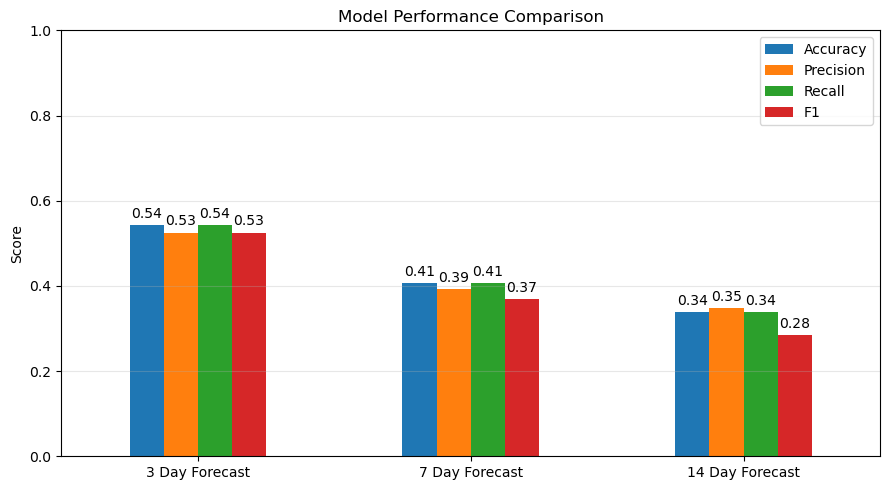

In [21]:
# define performance metrics
data = {
    'Accuracy': [0.542, 0.406, 0.338],
    'Precision': [0.525, 0.393, 0.347],
    'Recall': [0.542, 0.406, 0.338],
    'F1': [0.525, 0.369, 0.284]
}

# index corresponds to forecast
index = ['3 Day Forecast', '7 Day Forecast', '14 Day Forecast']

# create df
display_metrics = pd.DataFrame(data, index=index)

# plot metrics
ax = display_metrics.plot(kind='bar', figsize=(9, 5))
plt.title('Model Performance Comparison')
plt.ylabel('Score')
plt.ylim(0, 1.0)
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)
plt.legend(loc='upper right')

# add data labels on top of bars
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', label_type='edge', padding=3)

plt.tight_layout()
plt.show()